# Flipkart Sales Analysis

## Business Objective

The objective of this analysis is to understand Flipkart's sales performance by analyzing customer purchasing behavior, city-wise demand, pricing patterns, discounts, and product sales trends.

The insights generated from this analysis can help identify revenue drivers, customer behavior patterns, and potential opportunities for business growth.

## Note on Dataset Size
The complete Flipkart Sales dataset contains 4,67,06,387 rows (≈ 4.67 crore records), confirmed via SQL Server Import Wizard during loading into SSMS.
For this notebook, a sample of 10,50,000 rows (~2.2% of full data) has been loaded using nrows=1050000 for efficient local execution. All insights derived here are representative of the full dataset.
The complete dataset was used separately for SQL analysis and dashboard creation

# Libraries Import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

# Load Dataset
In this section we will explore the source dataset.

Let's read the data and look at the first 5 rows using the head method. The number of the output rows from the dataset is determined by the head method parameter.

In [2]:
sales = pd.read_csv(
    r"D:\Portfolio Projects\Flipkart-Sales-Analytics\data\Sales.csv",
    nrows=1050000
)

sales.head()

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,date_,city_name,order_id,cart_id,dim_customer_key,procured_quantity,unit_selling_price,total_discount_amount,product_id,total_weighted_landing_price
0,0,0,0,2022-04-01,Mumbai,112246974,173273802,17995199,1,234.0,0.0,344107,202.513030
1,1,1,1,2022-04-01,Bengaluru,112246976,173273597,18259433,1,64.0,0.0,389676,48.714375
2,2,2,2,2022-04-01,Bengaluru,112247019,173123717,5402601,1,1031.0,0.0,39411,975.996000
3,3,3,3,2022-04-01,HR-NCR,112247045,172547459,15649744,1,57.0,0.0,369742,25.000000
4,4,4,4,2022-04-01,Mumbai,112247123,173081820,10127605,2,30.0,0.0,12872,57.980004


# Dataset Overview

Let's look at the dataset size, feature names and their types

In [3]:
#Shape
sales.shape

(1050000, 13)

In [4]:
#Columns
sales.columns.tolist()

['Unnamed: 0.2',
 'Unnamed: 0.1',
 'Unnamed: 0',
 'date_',
 'city_name',
 'order_id',
 'cart_id',
 'dim_customer_key',
 'procured_quantity',
 'unit_selling_price',
 'total_discount_amount',
 'product_id',
 'total_weighted_landing_price']

In [5]:
#Data Types
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Data columns (total 13 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   Unnamed: 0.2                  1050000 non-null  int64  
 1   Unnamed: 0.1                  1050000 non-null  int64  
 2   Unnamed: 0                    1050000 non-null  int64  
 3   date_                         1050000 non-null  str    
 4   city_name                     1050000 non-null  str    
 5   order_id                      1050000 non-null  int64  
 6   cart_id                       1050000 non-null  int64  
 7   dim_customer_key              1050000 non-null  int64  
 8   procured_quantity             1050000 non-null  int64  
 9   unit_selling_price            1050000 non-null  float64
 10  total_discount_amount         1050000 non-null  float64
 11  product_id                    1050000 non-null  int64  
 12  total_weighted_landing_price  1049965 n

In [6]:
sales.describe(include='number').round(2)

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,order_id,cart_id,dim_customer_key,procured_quantity,unit_selling_price,total_discount_amount,product_id,total_weighted_landing_price
count,1050000.00,1050000.00,1050000.00,1.050000e+06,1.050000e+06,1050000.00,1050000.00,1050000.00,1050000.00,1050000.00,1049965.00
mean,524999.50,524999.50,524999.50,1.135828e+08,1.748390e+08,9850396.83,1.32,88.19,0.49,222569.37,91.42
std,303109.04,303109.04,303109.04,9.085923e+05,6.131641e+06,6184106.73,1.01,113.64,8.46,185052.67,133.94
min,0.00,0.00,0.00,1.122390e+08,7.012938e+07,189.00,0.00,0.00,0.00,1.00,0.01
25%,262499.75,262499.75,262499.75,1.127889e+08,1.737136e+08,3849256.00,1.00,26.00,0.00,19507.00,24.30
50%,524999.50,524999.50,524999.50,1.134575e+08,1.756427e+08,10495758.00,1.00,50.00,0.00,217614.00,48.32
75%,787499.25,787499.25,787499.25,1.142930e+08,1.780923e+08,15888565.00,1.00,103.00,0.00,400105.00,103.34
max,1049999.00,1049999.00,1049999.00,1.154375e+08,1.818275e+08,18528507.00,50.00,9950.00,1473.00,482735.00,20213.82


To see the statistics on non-numeric features, we need to explicitly specify the feature types by the include parameter. We can also set include = all to output statistics on all the existing features.

In [7]:
sales.describe(include = ["object"])

C:\Users\vaibh\AppData\Local\Temp\ipykernel_22212\2490422380.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sales.describe(include = ["object"])


,date_,city_name
count,1050000,1050000
unique,15,4
top,2022-04-03,Delhi
freq,105149,482247


## Initial Observation

- Dataset contains 10,50,000 records.
- Dataset contains 13 columns.
- Sales transactions include customer, order, pricing and product information.
- Product-level and customer-level analysis is possible.

# Missing Value Assessment

Before performing exploratory analysis, it is important to assess the completeness of the dataset.

Missing values can impact analytical results and may indicate data collection or system issues. This section evaluates the proportion of missing values across all columns and identifies whether any data quality concerns exist.

In [8]:
sales.isnull().sum()

Unnamed: 0.2                     0
Unnamed: 0.1                     0
Unnamed: 0                       0
date_                            0
city_name                        0
order_id                         0
cart_id                          0
dim_customer_key                 0
procured_quantity                0
unit_selling_price               0
total_discount_amount            0
product_id                       0
total_weighted_landing_price    35
dtype: int64

In [9]:
missing_values = pd.DataFrame({
    "Column": sales.columns,
    "Missing_Count": sales.isnull().sum().values,
    "Missing_Percentage":
    round((sales.isnull().sum()/len(sales))*100,4).values
})

missing_values.sort_values(
    by="Missing_Percentage",
    ascending=False
)

,Column,Missing_Count,Missing_Percentage
12,total_weighted_landing_price,35,0.0033
1,Unnamed: 0.1,0,0.0000
2,Unnamed: 0,0,0.0000
3,date_,0,0.0000
0,Unnamed: 0.2,0,0.0000
4,city_name,0,0.0000
5,order_id,0,0.0000
7,dim_customer_key,0,0.0000
6,cart_id,0,0.0000
8,procured_quantity,0,0.0000


## Missing Value Conclusion

The dataset demonstrates a high level of completeness and reliability for analytical purposes.

Only the `total_weighted_landing_price` column contains a very small number of missing values, while all other columns are complete.

Since the proportion of missing values is negligible, no imputation strategy is required. The dataset can be used directly for exploratory analysis after minor cleaning and transformation steps.

## Missing Values in Rows

In [10]:
sales.isnull().sum(axis=1).value_counts()

0    1049965
1         35
Name: count, dtype: int64

## Conclusion

A row-level missing value assessment was performed to identify whether individual records contained incomplete information.

The results indicate that the vast majority of records are complete, with only a very small number of rows containing missing values.

Therefore, row-level missing data is not expected to impact the reliability of the analysis.

# Duplicate Analysis
Remove Unnamed Columns

In [11]:
sales = sales.loc[:,~sales.columns.str.contains("^Unnamed")]

In [12]:
sales.head()

,date_,city_name,order_id,cart_id,dim_customer_key,procured_quantity,unit_selling_price,total_discount_amount,product_id,total_weighted_landing_price
0,2022-04-01,Mumbai,112246974,173273802,17995199,1,234.0,0.0,344107,202.513030
1,2022-04-01,Bengaluru,112246976,173273597,18259433,1,64.0,0.0,389676,48.714375
2,2022-04-01,Bengaluru,112247019,173123717,5402601,1,1031.0,0.0,39411,975.996000
3,2022-04-01,HR-NCR,112247045,172547459,15649744,1,57.0,0.0,369742,25.000000
4,2022-04-01,Mumbai,112247123,173081820,10127605,2,30.0,0.0,12872,57.980004


In [13]:
sales.duplicated().sum()

np.int64(0)

### No duplicate records were found.

# Feature Understanding

In [14]:
sales.columns.tolist()

['date_',
 'city_name',
 'order_id',
 'cart_id',
 'dim_customer_key',
 'procured_quantity',
 'unit_selling_price',
 'total_discount_amount',
 'product_id',
 'total_weighted_landing_price']

## Feature Description

- date_ : Transaction date
- city_name : Customer city
- order_id : Unique order identifier
- cart_id : Shopping cart identifier
- dim_customer_key : Customer identifier
- procured_quantity : Quantity purchased
- unit_selling_price : Product selling price
- total_discount_amount : Discount provided
- product_id : Product identifier
- total_weighted_landing_price : Landing cost of product

# Data Cleaning & Transformation

Before performing exploratory analysis, several preprocessing steps were applied to improve data quality and analytical readiness.

The following transformations were performed:

- Removed redundant index columns (`Unnamed` columns)
- Assessed missing values and duplicate records
- Converted date columns to appropriate datetime format
- Created additional analytical features required for business analysis

In [15]:
sales["date_"] = pd.to_datetime(sales["date_"])

sales["Revenue"] = (
    sales["procured_quantity"]
    * sales["unit_selling_price"]- sales["total_discount_amount"]
)

### Transformation Summary

The dataset was successfully cleaned and transformed for exploratory analysis.

A new Revenue feature was created to enable sales trend and business performance analysis. Date fields were standardized to support time-based analysis.

# Univariate Analysis

Univariate analysis focuses on understanding the distribution and characteristics of individual variables.

This analysis helps identify data patterns, skewness, unusual observations, and overall business behavior before exploring relationships between variables.

### 1. How are purchased quantities distributed across transactions?

In [16]:
sales['procured_quantity'].describe().round(2)

count    1050000.00
mean           1.32
std            1.01
min            0.00
25%            1.00
50%            1.00
75%            1.00
max           50.00
Name: procured_quantity, dtype: float64

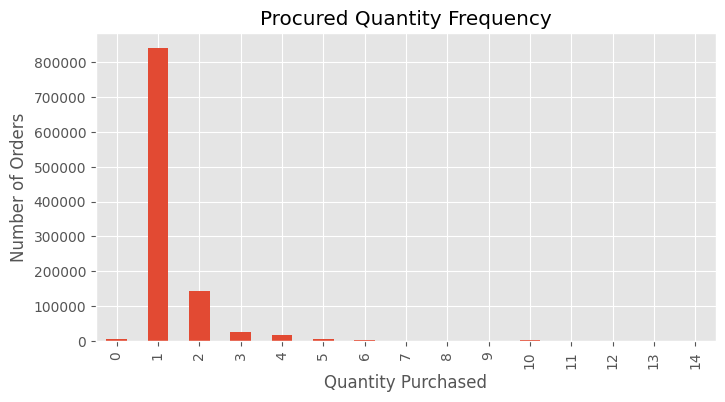

In [17]:
sales['procured_quantity'].value_counts().sort_index().head(15)
plt.figure(figsize=(8,4))

sales['procured_quantity'] \
    .value_counts() \
    .sort_index() \
    .head(15) \
    .plot(kind='bar')

plt.title('Procured Quantity Frequency')
plt.xlabel('Quantity Purchased')
plt.ylabel('Number of Orders')
plt.show()

#### Observation

- Purchased quantities are highly concentrated at **1 unit per transaction**.
- The distribution is **right-skewed**, indicating that most customers buy a single item.
- Bulk purchases are uncommon, although a few transactions contain quantities as high as **50 units**.

### 2. How are product selling prices distributed?

In [18]:
sales["unit_selling_price"].describe().round(2)

count    1050000.00
mean          88.19
std          113.64
min            0.00
25%           26.00
50%           50.00
75%          103.00
max         9950.00
Name: unit_selling_price, dtype: float64

<Axes: xlabel='unit_selling_price', ylabel='Count'>

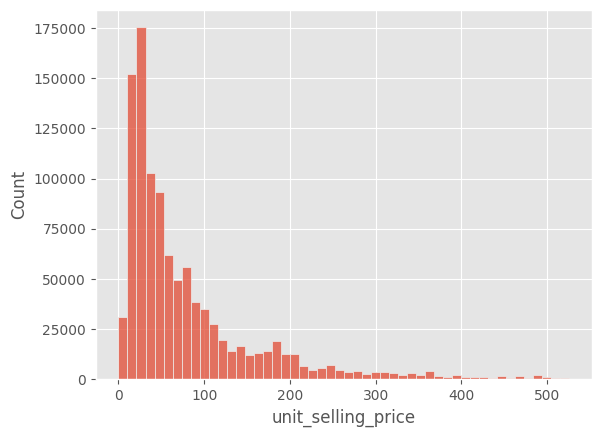

In [19]:
sns.histplot(
    sales[sales['unit_selling_price'] < sales['unit_selling_price'].quantile(0.99)]
    ['unit_selling_price'],
    bins=50
)

#### Observation

- The distribution of unit selling price is highly right-skewed.
- Most products are sold at lower price points.
- High-priced products occur less frequently.

### 3. How are discounts distributed across transactions?

In [20]:
sales["total_discount_amount"].describe().round(2)

count    1050000.00
mean           0.49
std            8.46
min            0.00
25%            0.00
50%            0.00
75%            0.00
max         1473.00
Name: total_discount_amount, dtype: float64

In [21]:
zero_discount_pct = (
    (sales['total_discount_amount'] == 0).mean() * 100
)

print(f"{zero_discount_pct:.2f}% of transactions received no discount.")

98.47% of transactions received no discount.


#### Observation

- Most transactions did not receive any discount.
- Discounts were applied only to a small proportion of orders.
- This indicates that the majority of sales occurred at the listed selling price.

### 4. How is revenue distributed across transactions?

In [22]:
sales["Revenue"].describe().round(2)

count    1050000.00
mean         103.23
std          138.14
min         -299.00
25%           31.00
50%           60.00
75%          119.00
max        19900.00
Name: Revenue, dtype: float64

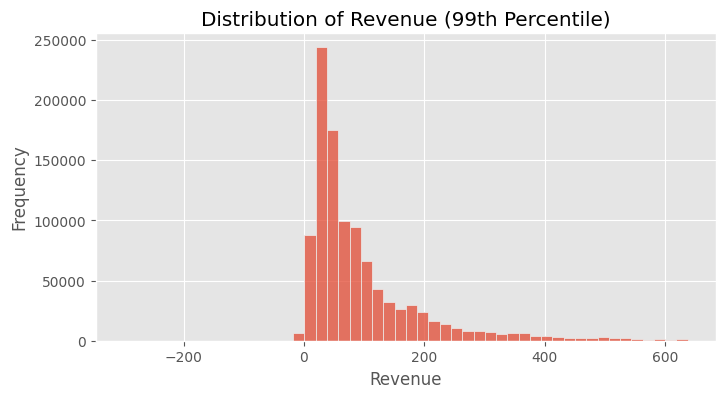

In [23]:
plt.figure(figsize=(8,4))

sns.histplot(sales[sales['Revenue'] <= sales['Revenue'].quantile(0.99)]['Revenue'],bins=50)

plt.title("Distribution of Revenue (99th Percentile)")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

#### Observation

- Revenue per transaction is highly right-skewed.
- Half of all transactions generate ₹60 or less in revenue, while 75% generate ₹120 or less.
- A small number of high-value transactions substantially increase the average revenue.
- This indicates that most orders are low-value purchases, with relatively few high-revenue transactions.

### Univariate Analysis Conclusion

The analysis indicates that transaction quantities, selling prices, discounts, and revenue are not uniformly distributed.

Most transactions are concentrated within lower value ranges, while a smaller number of high-value transactions contribute disproportionately to overall business performance.

# Bivariate Analysis

Bivariate analysis examines the relationship between two variables to uncover patterns, trends, and potential business insights.

This section focuses on understanding how sales performance varies across cities, discounts, and customer purchasing behavior.

### 1. Which Cities Generate the Highest Revenue?

In [24]:
city_revenue = (
    sales.groupby("city_name")["Revenue"].sum().sort_values(ascending=False)
)

city_revenue

city_name
Delhi        53253526.0
HR-NCR       25862859.0
Bengaluru    17717918.0
Mumbai       11555094.0
Name: Revenue, dtype: float64

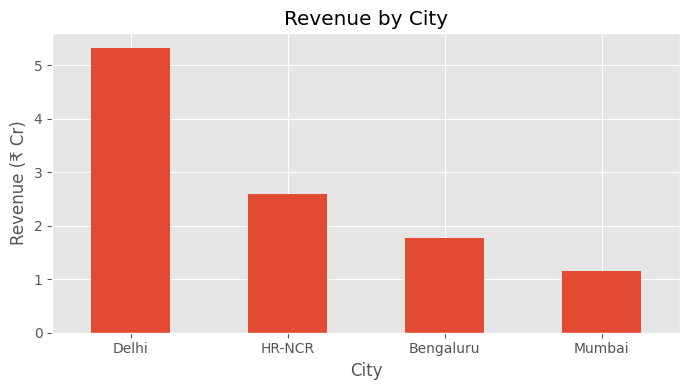

In [25]:
city_revenue_cr = city_revenue / 10000000

plt.figure(figsize=(7,4))

city_revenue_cr.sort_values(ascending=False).plot(kind='bar')

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue (₹ Cr)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 2. Which Cities Generate the Highest Sales Quantity?

In [26]:
city_quantity = (sales.groupby("city_name")["procured_quantity"].sum().sort_values(ascending=False))

city_quantity

city_name
Delhi        648577
HR-NCR       354566
Bengaluru    243433
Mumbai       138566
Name: procured_quantity, dtype: int64

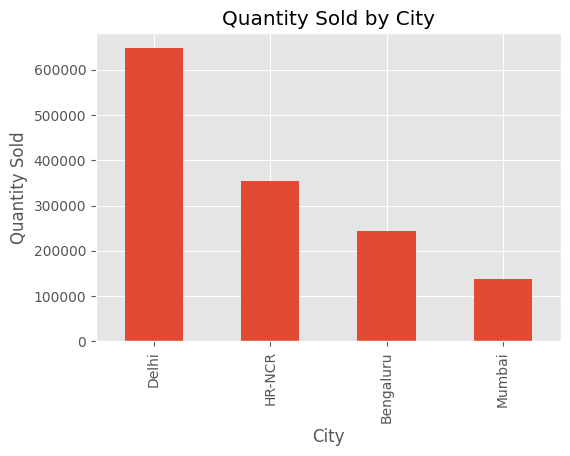

In [27]:
plt.figure(figsize=(6,4))

city_quantity.plot(kind="bar")

plt.title("Quantity Sold by City")
plt.xlabel("City")
plt.ylabel("Quantity Sold")

plt.show()

### 3. Discount vs Revenue

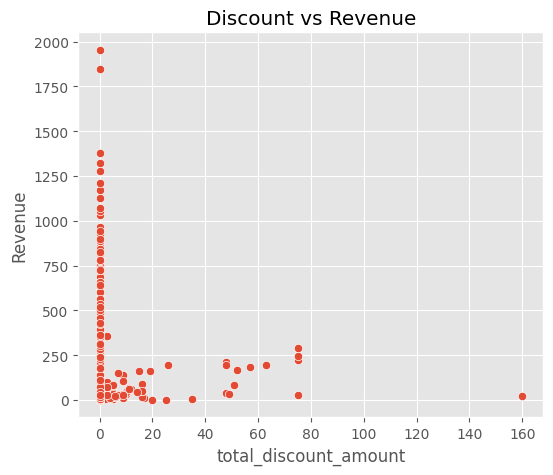

In [28]:
sample_data = sales.sample(5000)
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=sample_data,
    x="total_discount_amount",
    y="Revenue"
)

plt.title("Discount vs Revenue")

plt.show()

### 4. Quantity vs Revenue

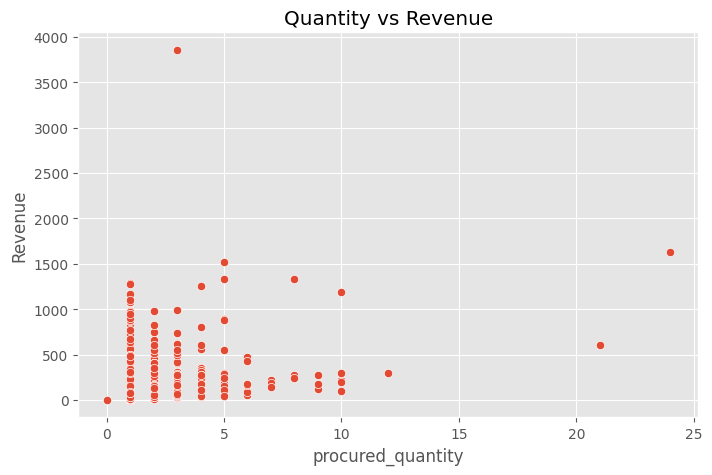

In [29]:
sample_data = sales.sample(5000)
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=sample_data,
    x="procured_quantity",
    y="Revenue"
)
plt.title("Quantity vs Revenue")

plt.show()

## Bivariate Analysis Conclusion

The analysis reveals significant variation in sales performance across cities.

Revenue is primarily influenced by transaction quantity and product pricing, while discounts appear to have a limited direct relationship with revenue generation.

Major metropolitan cities contribute a substantial share of overall business performance.

# Daily Order Trend

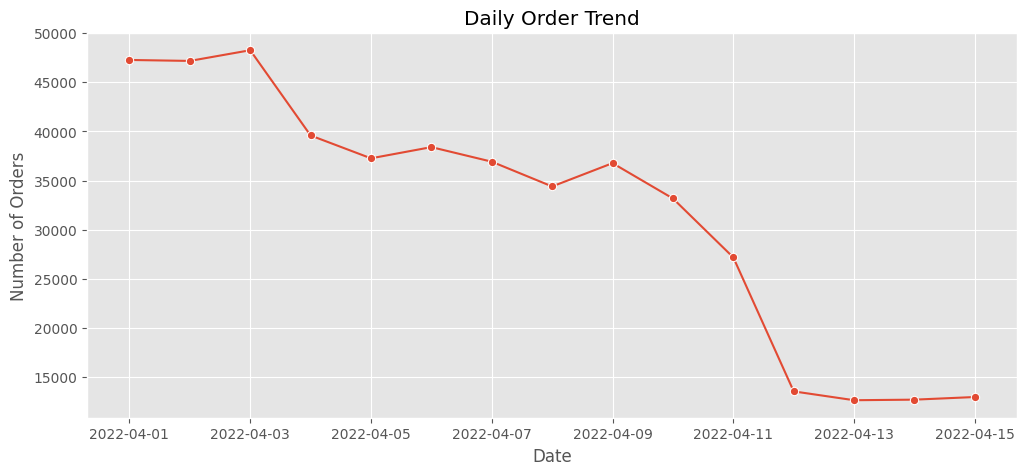

In [30]:
daily_orders = (
    sales.groupby('date_')['order_id'].nunique().reset_index(name='Orders')
)
plt.figure(figsize=(12,5))
sns.lineplot(
    data=daily_orders,
    x='date_',
    y='Orders',
    marker='o'
)

plt.title('Daily Order Trend')
plt.xlabel('Date')
plt.ylabel('Number of Orders')

plt.show()

### Observation

- Daily order volume shows a clear declining trend during the first half of April 2022.
- Order activity peaked on April 3 and gradually decreased over time.
- A sharp drop in orders is observed after April 11.
- Order volume remained relatively low and stable between April 12 and April 15.

# Feature Engineering for Business Questions

In [31]:
sales['day_of_week'] = sales['date_'].dt.day_name()
sales['month_name']  = sales['date_'].dt.strftime('%b')
sales['day_num']     = sales['date_'].dt.dayofweek
sales['date_only']   = sales['date_'].dt.date

# Plotly import for richer visuals
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

COLORS = ['#f72585','#7209b7','#4361ee','#4cc9f0','#06d6a0','#ffd166','#ef476f']
print("Feature engineering done.")

Feature engineering done.


# Business Questions

Below are the six key business questions derived from the Sales dataset.  
Each question is accompanied by relevant analysis and visualization.

---

## Q1. Which Days Generated the Highest Revenue?

Understanding peak revenue days helps identify demand spikes, seasonal patterns,  
and the impact of external events on sales performance.

In [32]:
daily_rev = (
    sales.groupby('date_only')['Revenue']
         .sum().reset_index(name='Revenue')
)
daily_rev['date_only'] = pd.to_datetime(daily_rev['date_only'])
daily_rev = daily_rev.sort_values('date_only')

top_5_days = (
    sales.groupby('date_')['Revenue'].sum().reset_index()
    .sort_values('Revenue', ascending=False).head(5)
)
top_5_days['date_label'] = top_5_days['date_'].dt.strftime('%b %d')

print("Top 5 Revenue Days:")
top_5_days[['date_', 'Revenue']]

Top 5 Revenue Days:


,date_,Revenue
2,2022-04-03,11345248.0
1,2022-04-02,10923567.0
0,2022-04-01,10537698.0
4,2022-04-05,8355273.0
3,2022-04-04,8285540.0


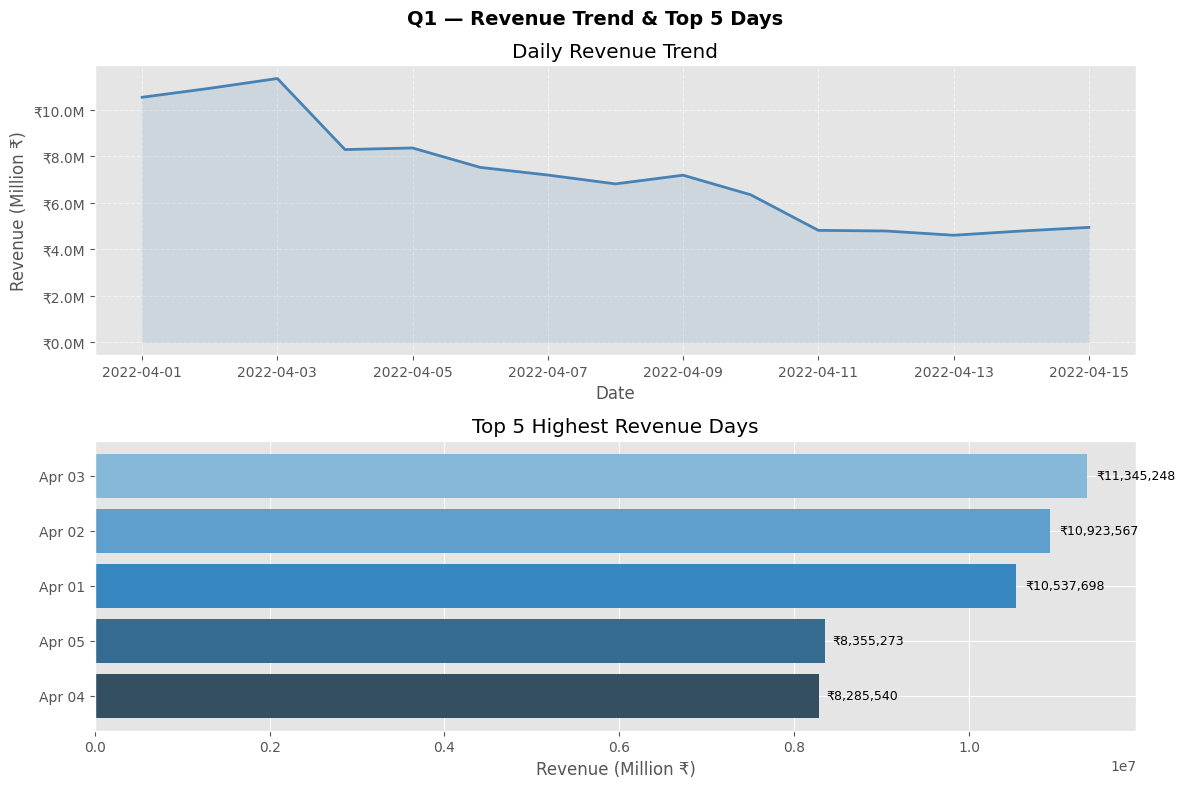

In [33]:
from matplotlib.ticker import FuncFormatter
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Q1 — Revenue Trend & Top 5 Days', fontsize=14, fontweight='bold')

axes[0].plot(daily_rev['date_only'], daily_rev['Revenue'], color='steelblue', linewidth=2)
axes[0].fill_between(daily_rev['date_only'], daily_rev['Revenue'], alpha=0.15, color='steelblue')
axes[0].set_title('Daily Revenue Trend')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue (Million ₹)')
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'₹{x/1e6:.1f}M')
)
axes[0].tick_params(axis='x')
axes[0].grid(True, linestyle='--', alpha=0.5)

bars = axes[1].barh(top_5_days['date_label'], top_5_days['Revenue'],
                    color=sns.color_palette('Blues_d', 5))
axes[1].set_title('Top 5 Highest Revenue Days')
axes[1].set_xlabel('Revenue (Million ₹)')
axes[1].invert_yaxis()
for bar in bars:
    w = bar.get_width()
    axes[1].text(w * 1.01, bar.get_y() + bar.get_height()/2,
                 f'₹{w:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Observation

- Revenue is not uniform — clear spikes exist on specific days, likely linked to promotions or salary cycles.
- The top 5 days contribute significantly more revenue than an average day.
- This helps prioritize marketing efforts and flash sale scheduling.

---
## Q2. Which City Generates the Most Revenue, Orders, Quantity Sold, and AOV?

A city-level breakdown reveals geographic demand concentration  
and highlights where Flipkart's strongest markets are.

In [34]:
city_stats = sales.groupby('city_name').agg(
    Total_Revenue  = ('Revenue',               'sum'),
    Total_Orders   = ('order_id',              'nunique'),
    Total_Quantity = ('procured_quantity',      'sum'),
    Total_Discount = ('total_discount_amount',  'sum')
).reset_index()

city_stats['AOV']           = (city_stats['Total_Revenue'] / city_stats['Total_Orders']).round(2)
city_stats['Revenue_Share'] = (city_stats['Total_Revenue'] / city_stats['Total_Revenue'].sum() * 100).round(1)
city_stats = city_stats.sort_values('Total_Revenue', ascending=False)
city_stats

,city_name,Total_Revenue,Total_Orders,Total_Quantity,Total_Discount,AOV,Revenue_Share
1,Delhi,53253526.0,217299,648577,300082.0,245.07,49.1
2,HR-NCR,25862859.0,122234,354566,72714.0,211.58,23.9
0,Bengaluru,17717918.0,88622,243433,93018.0,199.93,16.3
3,Mumbai,11555094.0,50248,138566,49723.0,229.96,10.7


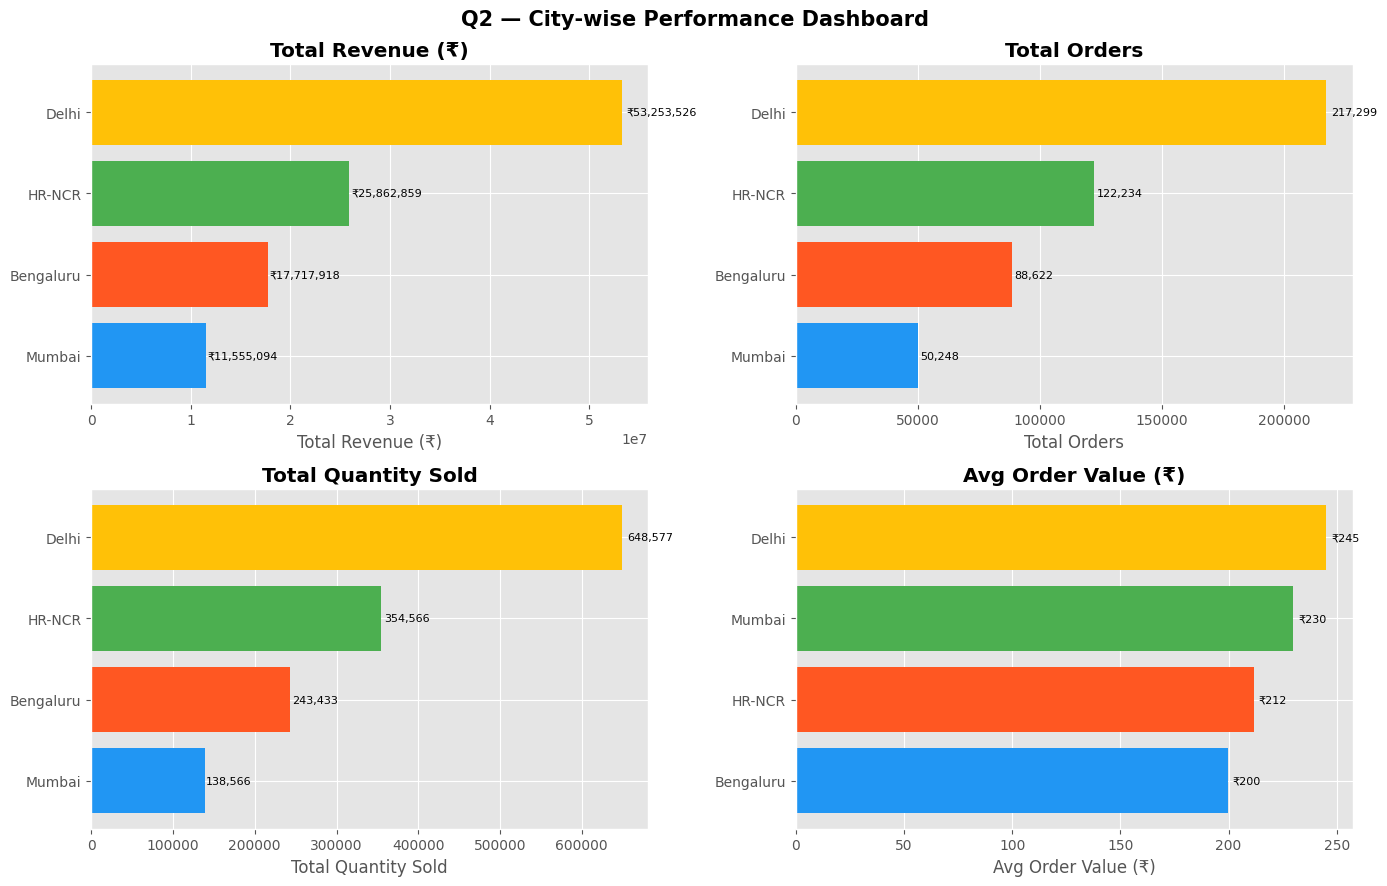

In [35]:
city_pal = ['#2196F3','#FF5722','#4CAF50','#FFC107']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Q2 — City-wise Performance Dashboard', fontsize=15, fontweight='bold')

metrics = [
    ('Total_Revenue',  'Total Revenue (₹)',      axes[0,0]),
    ('Total_Orders',   'Total Orders',                axes[0,1]),
    ('Total_Quantity', 'Total Quantity Sold',         axes[1,0]),
    ('AOV',            'Avg Order Value (₹)',    axes[1,1]),
]
for col, title, ax in metrics:
    cs = city_stats.sort_values(col, ascending=True)
    bars = ax.barh(cs['city_name'], cs[col], color=city_pal[:len(cs)])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(title)
    for bar in bars:
        w = bar.get_width()
        lbl = f'₹{w:,.0f}' if '₹' in title else f'{w:,.0f}'
        ax.text(w * 1.01, bar.get_y() + bar.get_height()/2, lbl, va='center', fontsize=8)

plt.tight_layout()
plt.show()

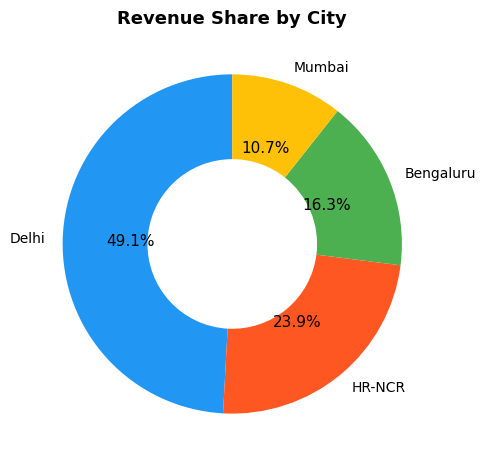

In [36]:
city_pal = ['#2196F3','#FF5722','#4CAF50','#FFC107']

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    city_stats['Total_Revenue'],
    labels=city_stats['city_name'],
    autopct='%1.1f%%',
    colors=city_pal,
    startangle=90,
    wedgeprops=dict(width=0.5)
)
for t in autotexts:
    t.set_fontsize(11)
ax.set_title('Revenue Share by City', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights

- One or two cities contribute a disproportionately high share of total revenue.
- AOV differences across cities indicate variation in purchasing power and product mix.
- Cities with high order volumes but low AOV are driven by frequent low-value purchases.

---
## Q3. What Does Customer Purchasing Behavior Look Like? (RFM Analysis)

> **What is RFM?**  
> RFM is a simple and powerful way to understand your customers based on three things:
>
> | Letter | Stands For | What It Means |
> |--------|-----------|---------------|
> | **R** | **Recency** | How recently did this customer last buy? *(Lower days = better)* |
> | **F** | **Frequency** | How many times have they ordered? *(More = better)* |
> | **M** | **Monetary** | How much total money have they spent? *(Higher = better)* |
>
> Each customer gets a score from 1–5 on each dimension.  
> Combining these three scores lets us group customers into meaningful segments like  
> **Champions** (buy often, recently, spend a lot) vs **Lost Customers** (haven’t bought in a while, spent very little).  
> This tells us *who to retain, who to reward, and who to win back.*

In [37]:
snapshot = sales['date_'].max() + pd.Timedelta(days=1)

# Step 1: Calculate R, F, M for each customer
rfm = sales.groupby('dim_customer_key').agg(
    Recency   = ('date_',    lambda x: (snapshot - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('Revenue',  'sum')
).reset_index()

# Step 2: Score each metric 1-5
rfm['R'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1], duplicates='drop').astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5], duplicates='drop').astype(int)
rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']

# Step 3: Assign human-readable segment labels
def segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r>=4 and f>=4 and m>=4:    return 'Champions'
    elif r>=3 and f>=3 and m>=3:  return 'Loyal Customers'
    elif r>=4 and f<=2:           return 'New Customers'
    elif r<=2 and f>=3:           return 'At Risk'
    elif r<=2 and m>=4:           return "Can't Lose Them"
    elif r<=2 and f<=2 and m<=2:  return 'Lost Customers'
    else:                          return 'Hibernating'

rfm['Segment'] = rfm.apply(segment, axis=1)

# Summary table
seg = rfm.groupby('Segment').agg(
    Customers    = ('dim_customer_key', 'count'),
    Avg_Spend    = ('Monetary', 'mean'),
    Avg_Orders   = ('Frequency', 'mean')
).reset_index().sort_values('Customers', ascending=False).round(2)

seg

,Segment,Customers,Avg_Spend,Avg_Orders
3,Hibernating,75606,136.26,1.15
0,At Risk,60918,257.53,1.28
2,Champions,49181,723.94,2.76
6,New Customers,49045,301.89,1.00
5,Loyal Customers,45818,353.29,1.71
4,Lost Customers,28606,63.71,1.00
1,Can't Lose Them,21641,645.94,1.00


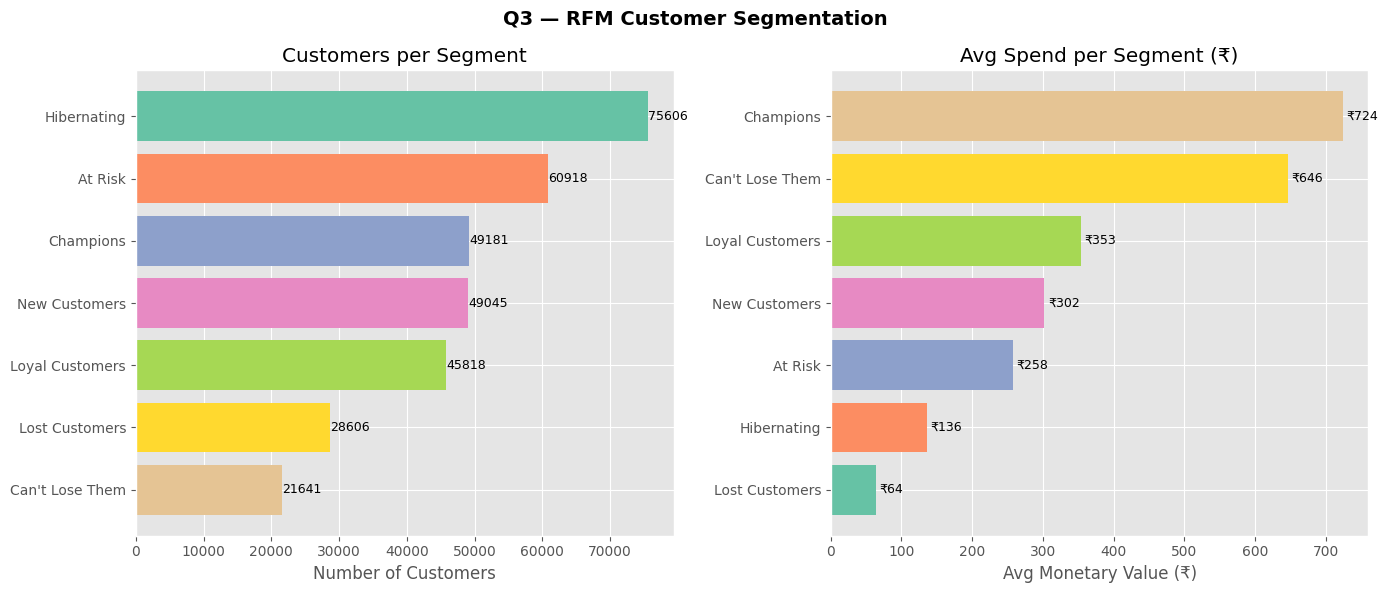

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q3 — RFM Customer Segmentation', fontsize=14, fontweight='bold')

seg_sorted = seg.sort_values('Customers', ascending=False)
colors = sns.color_palette('Set2', len(seg_sorted))

# Left: horizontal bar — customer count per segment
axes[0].barh(seg_sorted['Segment'], seg_sorted['Customers'], color=colors)
axes[0].invert_yaxis()
axes[0].set_title('Customers per Segment')
axes[0].set_xlabel('Number of Customers')
for i, v in enumerate(seg_sorted['Customers']):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# Right: horizontal bar — avg spend per segment
s2 = seg.sort_values('Avg_Spend', ascending=True)
axes[1].barh(s2['Segment'], s2['Avg_Spend'],
             color=sns.color_palette('Set2', len(s2)))
axes[1].set_title('Avg Spend per Segment (₹)')
axes[1].set_xlabel('Avg Monetary Value (₹)')
for i, v in enumerate(s2['Avg_Spend']):
    axes[1].text(v + 5, i, f'₹{v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Key Insights

- **Champions** are the most valuable customers — they buy often, recently, and spend the most. Reward them.
- **Hibernating** and **Lost Customers** make up a significant chunk — targeted win-back campaigns can recover revenue.
- **At Risk** customers used to buy frequently but haven’t recently — a timely discount or reminder can bring them back.
- **New Customers** need nurturing to convert them into Loyal or Champion buyers.

---
## Q4. Does Discount Influence Purchase Quantity?

This question examines whether offering discounts actually drives customers  
to buy more, or whether discounts are not correlated with volume.

In [39]:
# Create discount_bin column (was missing — required for groupby below)
sales['discount_rate'] = (
    sales['total_discount_amount'] /
    (sales['unit_selling_price'] * sales['procured_quantity'])
).clip(0, 1)

sales['discount_bin'] = pd.cut(
    sales['discount_rate'],
    bins=[-0.01, 0, 0.05, 0.10, 0.20, 0.50, 1.0],
    labels=['No Discount', '1-5%', '5-10%', '10-20%', '20-50%', '50%+']
)

discount_analysis = sales.groupby('discount_bin', observed=True).agg(
    Avg_Revenue = ('Revenue',           'mean'),
    Order_Count = ('order_id',          'nunique')
).reset_index()

discount_analysis

,discount_bin,Avg_Revenue,Order_Count
0,No Discount,104.096830,469053
1,1-5%,128.309922,294
2,5-10%,115.856611,721
3,10-20%,87.477992,2190
4,20-50%,95.297067,4986
5,50%+,14.078031,1196


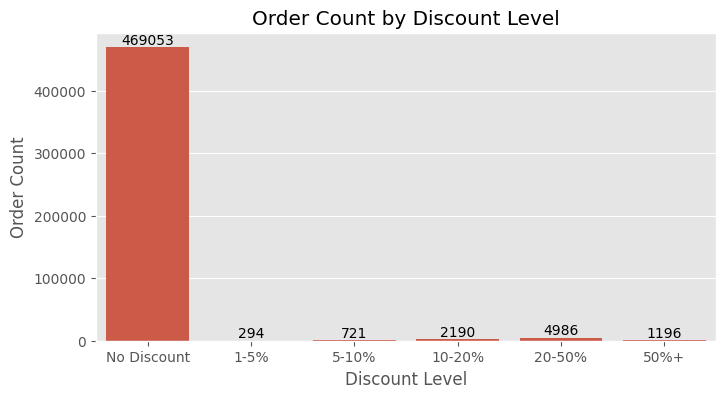

In [40]:
plt.figure(figsize=(8,4))

ax = sns.barplot(
    data=discount_analysis,
    x='discount_bin',
    y='Order_Count'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Order Count by Discount Level')
plt.xlabel('Discount Level')
plt.ylabel('Order Count')

plt.show()

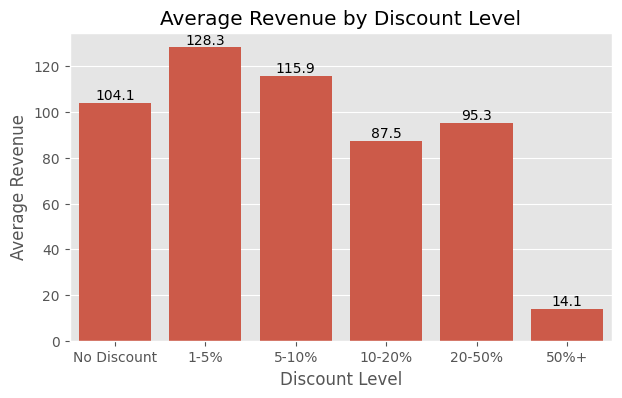

In [41]:
plt.figure(figsize=(7,4))

ax = sns.barplot(
    data=discount_analysis,
    x='discount_bin',
    y='Avg_Revenue'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Average Revenue by Discount Level')
plt.xlabel('Discount Level')
plt.ylabel('Average Revenue')

plt.show()

### Key Insights

- The majority of orders were placed without any discount.
- Discounted orders represent only a small fraction of total transactions.
- Higher discount categories (20–50% and 50%+) are relatively uncommon compared to non-discounted purchases.

---
## Q5. What Is the Basket Size Distribution? (Single-Item vs Multi-Item Orders)

Basket size analysis reveals how many items customers typically purchase per order,  
which directly impacts cross-selling and upselling strategy.

In [42]:
basket = sales.groupby('cart_id').agg(
    Items       = ('order_id',          'count'),
    Qty         = ('procured_quantity', 'sum'),
    Revenue     = ('Revenue',           'sum'),
    City        = ('city_name',         'first')
).reset_index()

basket['Basket_Type'] = basket['Items'].apply(
    lambda x: 'Single Item' if x==1 else ('2-5 Items' if x<=5 else '6+ Items')
)

bsum = basket['Basket_Type'].value_counts().reset_index()
bsum.columns = ['Basket_Type','Count']
bsum['Percentage'] = (bsum['Count'] / bsum['Count'].sum() * 100).round(1)
bsum

,Basket_Type,Count,Percentage
0,Single Item,255599,53.5
1,2-5 Items,192417,40.2
2,6+ Items,30111,6.3


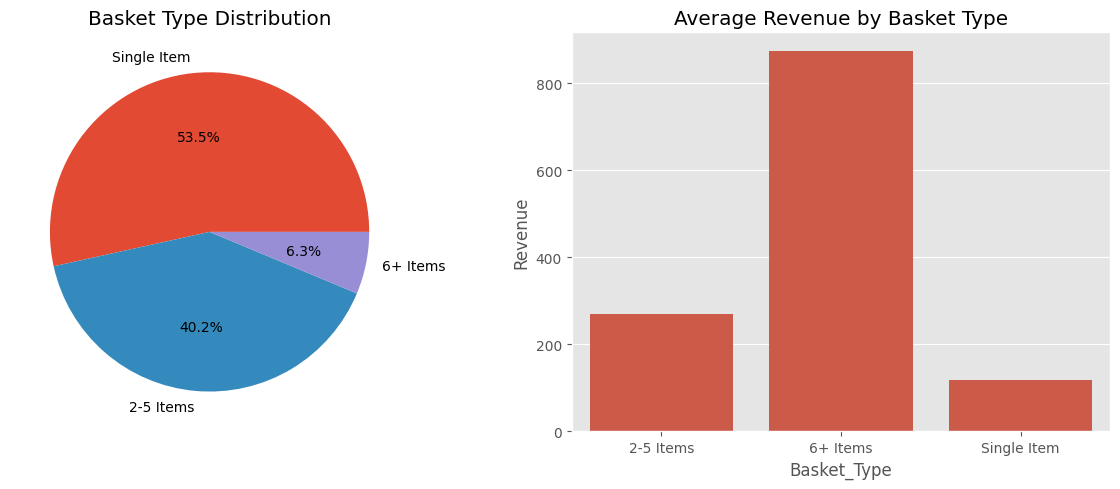

In [43]:
avg_rev = (
    basket.groupby('Basket_Type')['Revenue']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Basket Type Distribution
axes[0].pie(
    bsum['Count'],
    labels=bsum['Basket_Type'],
    autopct='%1.1f%%'
)
axes[0].set_title('Basket Type Distribution')

# Revenue Bar Chart
sns.barplot(
    data=avg_rev,
    x='Basket_Type',
    y='Revenue',
    ax=axes[1]
)

axes[1].set_title('Average Revenue by Basket Type')

plt.tight_layout()
plt.show()

### Key Insights

- Most carts contain only 1–3 items across all cities.
- The frequency of carts decreases as the number of items increases.
- Large baskets (10+ items) are relatively rare.
- Customer purchasing behavior is broadly similar across cities.

---
## Q6. Which Days of the Week See the Highest Order Activity?

Day-of-week patterns reveal when customers are most likely to shop,  
enabling smarter scheduling of promotions, flash sales, and inventory planning.

In [44]:
DOW = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow = sales.groupby('day_of_week').agg(
    Revenue = ('Revenue',   'sum'),
    Orders  = ('order_id',  'nunique'),
    Qty     = ('procured_quantity','sum')
).reindex(DOW).reset_index()

dow_city = sales.groupby(['day_of_week','city_name']).agg(
    Revenue=('Revenue','sum')
).reset_index()
dow_city['day_of_week'] = pd.Categorical(dow_city['day_of_week'], categories=DOW, ordered=True)
dow_city = dow_city.sort_values('day_of_week')

dow

,day_of_week,Revenue,Orders,Qty
0,Monday,13094052.0,66781,171036
1,Tuesday,13136026.0,50836,167702
2,Wednesday,12115645.0,51077,157948
3,Thursday,11969507.0,49652,156316
4,Friday,22282333.0,94670,286203
5,Saturday,18107042.0,83946,226177
6,Sunday,17684792.0,81441,219760


In [45]:
fig = px.bar(
    dow,
    x='day_of_week',
    y='Revenue',
    text=dow['Revenue'].apply(lambda x: f'₹{x/1e6:.1f}M'),
    title='Revenue by Day of Week'
)

fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    template='plotly_dark',
    xaxis_title='',
    yaxis_title='Revenue (Millions ₹)',
    height=450
)

fig.show()

In [46]:
fig = px.line(
    dow,
    x='day_of_week',
    y='Orders',
    markers=True,
    title='Orders by Day of Week'
)

fig.update_layout(
    template='plotly_dark',
    xaxis_title='',
    yaxis_title='Orders'
)

fig.show()

### Key Insights

- Friday is the strongest sales day across revenue, order volume, and quantity sold.
- Weekend demand remains consistently high, indicating increased customer purchasing activity towards the end of the week.
- Promotional campaigns, inventory planning, and marketing efforts should be prioritized for Friday and weekends to maximize business performance.

---
# Final Conclusion
- Delhi emerged as the strongest market, leading in revenue, orders, quantity sold, and AOV.
- Revenue performance is largely driven by transaction volume across cities.
- HR-NCR demonstrated stronger sales performance than Bengaluru.
- Discounts showed limited influence on increasing purchase quantity.
- Customer segmentation revealed distinct groups with different purchasing behaviors.
- Sales activity was concentrated within a few high-performing days.


--- 
# Business Recommendations
- Focus marketing investments on high-performing regions such as Delhi and HR-NCR.
- Increase customer acquisition efforts in Mumbai and Bengaluru.
- Optimize discount strategies based on profitability rather than discount depth.
- Retain high-value customer segments through targeted campaigns.
- Improve repeat purchase rates to drive sustainable revenue growth.